1. Upload your dataset in Colab

In [1]:
from google.colab import files
uploaded = files.upload()

Saving edu.csv to edu (1).csv


In [2]:
file_name = "edu.csv"

Import libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Load the Dataset

In [4]:
file_name = "edu.csv"   # change if your file name is different
df = pd.read_csv(file_name)
df.head()

,country,date,GNP,Population,Edu_prime,Edu_second,Edu_post_second,Edu_lower_second,Unemp,c_codes
0,ARAB WORLD,2017,16997.503539,414491886.0,NaN,NaN,NaN,NaN,NaN,NaN
1,ARAB WORLD,2016,16794.064949,406452690.0,83.911949,NaN,NaN,NaN,NaN,NaN
2,ARAB WORLD,2015,16366.596405,398304960.0,84.720306,NaN,NaN,NaN,NaN,NaN
3,ARAB WORLD,2014,15895.251480,390043028.0,85.314812,NaN,NaN,NaN,NaN,NaN
4,ARAB WORLD,2013,15453.220686,381702086.0,84.703484,NaN,NaN,NaN,NaN,NaN


Describe Dataset

In [28]:
df.describe()

,date,GNP,Population,Edu_prime,Edu_second,Edu_post_second,Edu_lower_second,Unemp
count,15312.000000,6277.000000,1.514700e+04,6441.000000,870.000000,790.000000,976.000000,1692.000000
mean,1988.500000,12491.472098,2.060462e+08,78.546217,49.265608,18.708057,58.146177,7.285639
std,16.741216,15285.379888,6.793067e+08,24.383345,25.871478,13.793191,28.948362,7.020108
min,1960.000000,230.000000,4.279000e+03,1.521950,0.000000,0.000000,0.600000,0.440000
25%,1974.000000,2540.000000,9.250650e+05,62.029930,27.684260,7.189883,35.586444,3.481375
50%,1988.500000,6720.000000,6.344722e+06,87.888527,49.328899,15.727490,58.988699,5.179450
75%,2003.000000,16524.097296,4.219871e+07,96.935547,73.771906,29.815498,84.879721,7.766818
max,2017.000000,128060.000000,7.530360e+09,186.054626,96.308228,69.071663,100.000000,65.089996


Check Basic Information

In [5]:
print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

Shape of dataset: (15312, 10)

Columns:
Index(['country', 'date', 'GNP', 'Population', 'Edu_prime', 'Edu_second',
       'Edu_post_second', 'Edu_lower_second', 'Unemp', 'c_codes'],
      dtype='object')

Data types:
country              object
date                  int64
GNP                 float64
Population          float64
Edu_prime           float64
Edu_second          float64
Edu_post_second     float64
Edu_lower_second    float64
Unemp               float64
c_codes              object
dtype: object


Check Missing Values

In [6]:
missing_values = df.isnull().sum()
print("Missing values in each column:")
print(missing_values)

Missing values in each column:
country                 0
date                    0
GNP                  9035
Population            165
Edu_prime            8871
Edu_second          14442
Edu_post_second     14522
Edu_lower_second    14336
Unemp               13620
c_codes              4756
dtype: int64


Duplicate


In [29]:
df.duplicated().sum()

np.int64(0)

Remove Duplicate

In [30]:
df = df.drop_duplicates()

Visualize missing values with bar chart

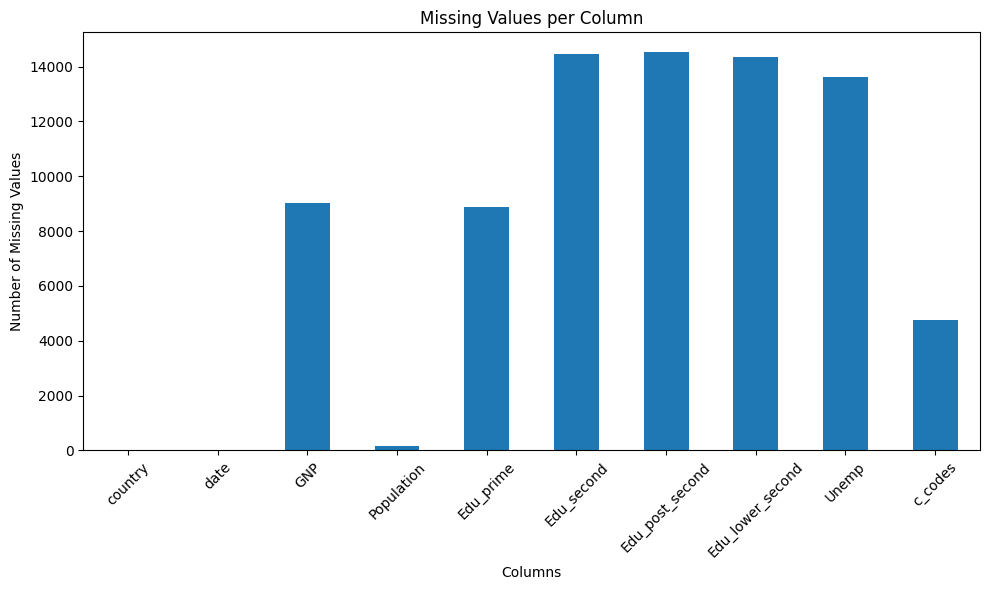

In [7]:
plt.figure(figsize=(10,6))
missing_values.plot(kind='bar')
plt.title("Missing Values per Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Make a copy of the dataset before cleaning

In [8]:
clean_df = df.copy()

Fill Missing Values

In [9]:
for col in clean_df.columns:
    if clean_df[col].dtype in ['int64', 'float64']:
        clean_df[col] = clean_df[col].fillna(clean_df[col].median())
    else:
        clean_df[col] = clean_df[col].fillna(clean_df[col].mode()[0])

Check if missing values are removed

In [10]:
print("Missing values after cleaning:")
print(clean_df.isnull().sum())

Missing values after cleaning:
country             0
date                0
GNP                 0
Population          0
Edu_prime           0
Edu_second          0
Edu_post_second     0
Edu_lower_second    0
Unemp               0
c_codes             0
dtype: int64


Save cleaned dataset

In [11]:
clean_df.to_csv("edu_cleaned.csv", index=False)
print("Cleaned dataset saved as edu_cleaned.csv")

Cleaned dataset saved as edu_cleaned.csv


Download cleaned dataset

In [12]:
from google.colab import files
files.download("edu_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Calculate Mean

In [21]:
mean_gnp = df["GNP"].mean()
print("Mean of GNP:", mean_gnp)

Mean of GNP: 12491.472097895174


Diagram
 Correlation heatmap

Calculate Median

In [22]:
median_population = df["Population"].median()
print("Median of Population:", median_population)

Median of Population: 6344722.0


Calculate Mode

In [23]:
mode_country = df["country"].mode()[0]
print("Mode of Country:", mode_country)

Mode of Country: AFGHANISTAN


Correlation Heatmap


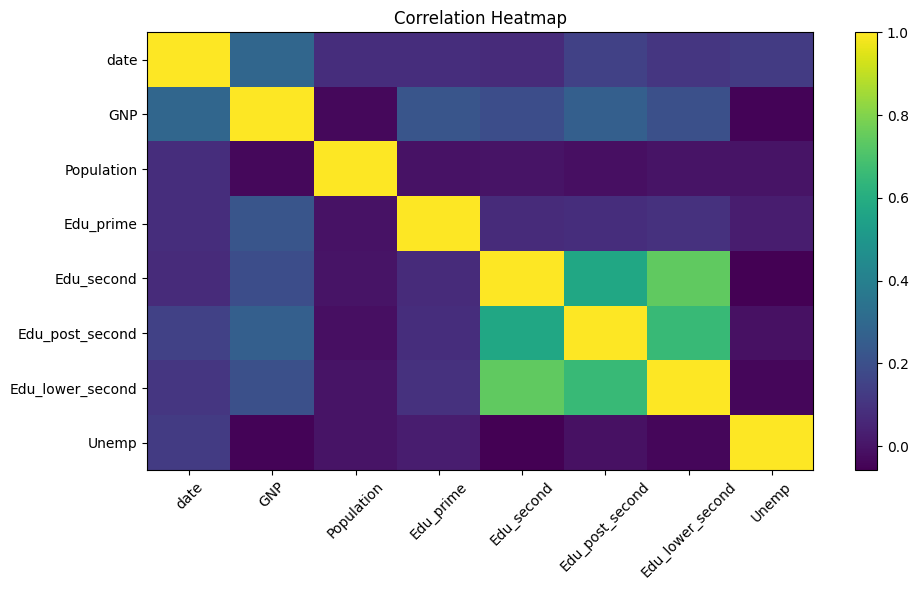

In [13]:
numeric_df = clean_df.select_dtypes(include=np.number)
corr = numeric_df.corr()

plt.figure(figsize=(10,6))
plt.imshow(corr, aspect='auto')
plt.colorbar()
plt.title("Correlation Heatmap")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.tight_layout()
plt.show()

Bar chart for a categorical column

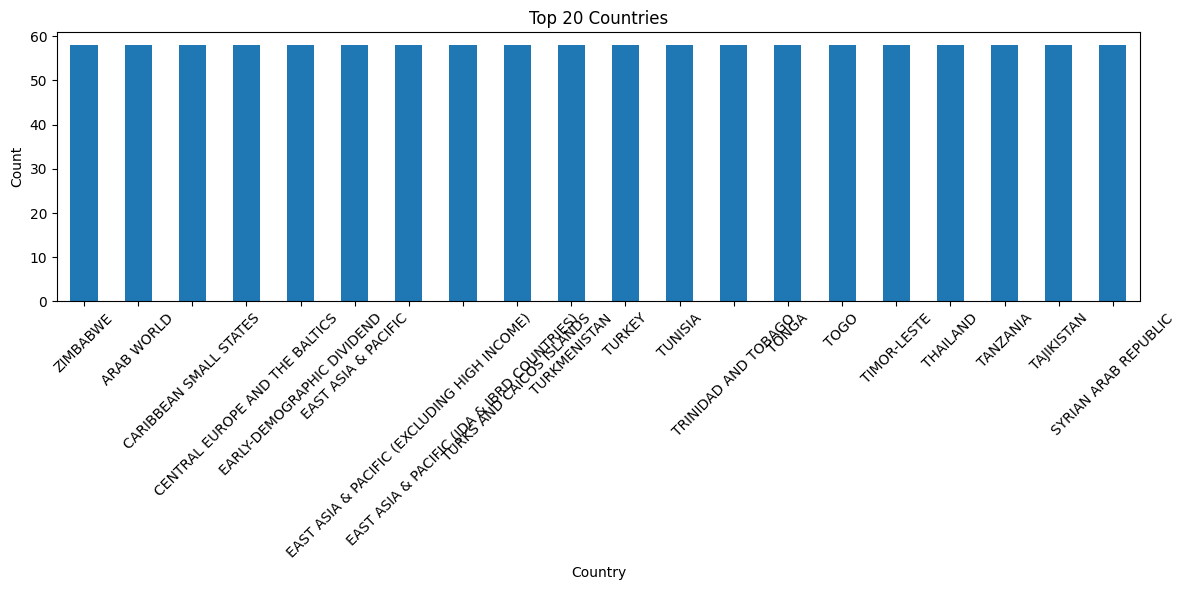

In [14]:
plt.figure(figsize=(12,6))
clean_df['country'].value_counts().head(20).plot(kind='bar')
plt.title("Top 20 Countries")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Histogram for numeric columns

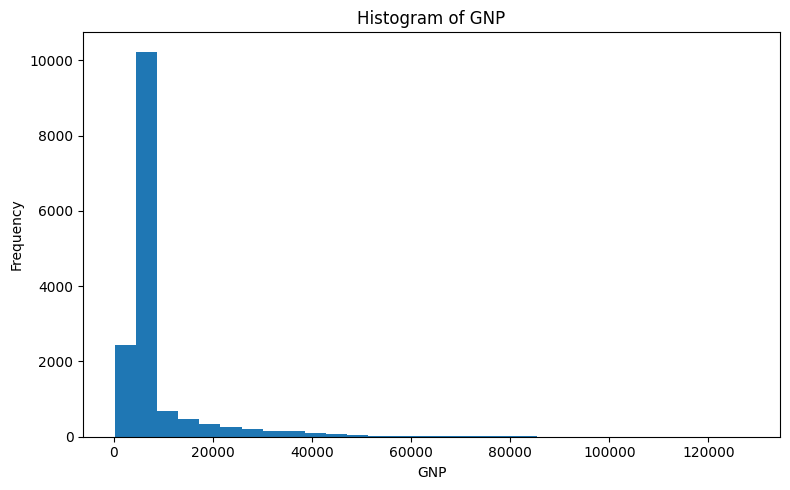

In [15]:
plt.figure(figsize=(8,5))
clean_df['GNP'].plot(kind='hist', bins=30)
plt.title("Histogram of GNP")
plt.xlabel("GNP")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Population:

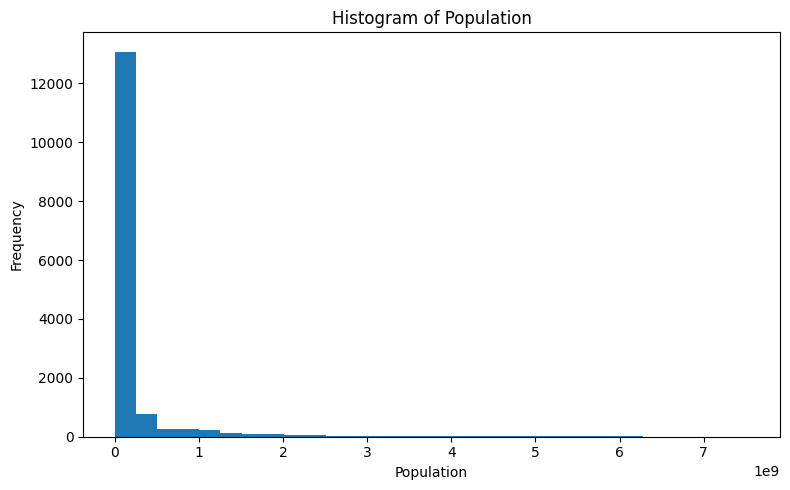

In [16]:
plt.figure(figsize=(8,5))
clean_df['Population'].plot(kind='hist', bins=30)
plt.title("Histogram of Population")
plt.xlabel("Population")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Boxplot for outlier detection

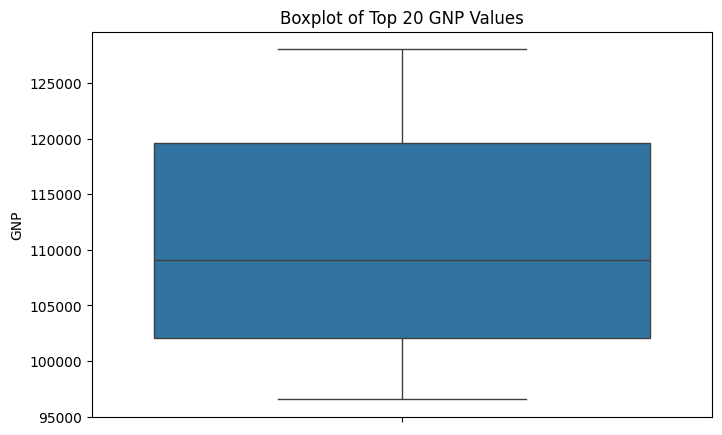

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

top20_gnp = clean_df.nlargest(20, 'GNP')['GNP']

plt.figure(figsize=(8,5))

sns.boxplot(y=top20_gnp)

plt.title("Boxplot of Top 20 GNP Values")
plt.ylabel("GNP")

plt.show()

Line chart for trend over time

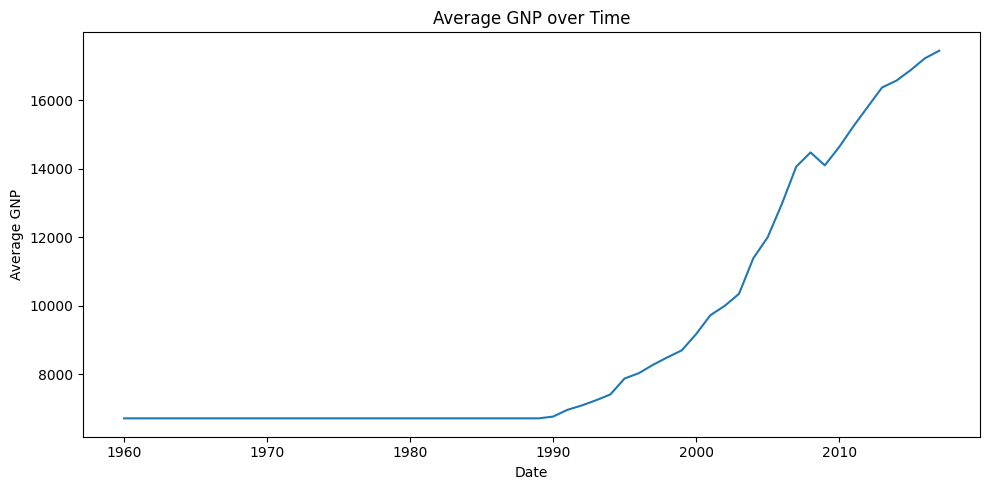

In [19]:
yearwise = clean_df.groupby('date')['GNP'].mean()

plt.figure(figsize=(10,5))
plt.plot(yearwise.index, yearwise.values)
plt.title("Average GNP over Time")
plt.xlabel("Date")
plt.ylabel("Average GNP")
plt.tight_layout()
plt.show()

Scatter plot between two numeric columns

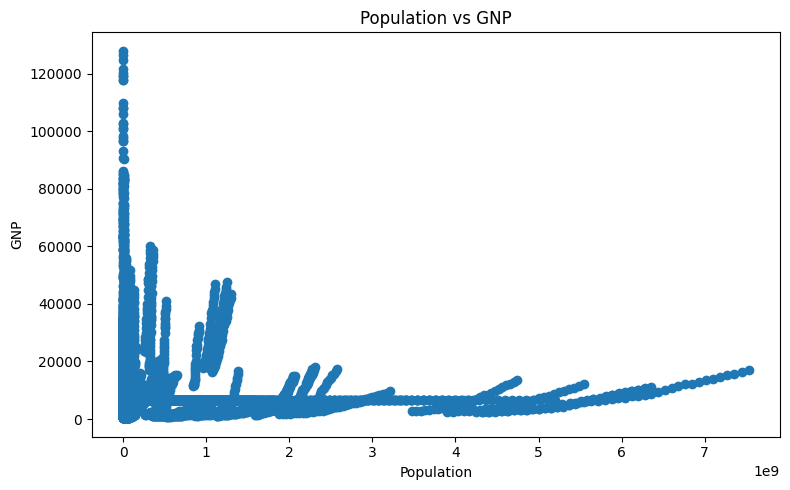

In [20]:
plt.figure(figsize=(8,5))
plt.scatter(clean_df['Population'], clean_df['GNP'])
plt.title("Population vs GNP")
plt.xlabel("Population")
plt.ylabel("GNP")
plt.tight_layout()
plt.show()

Pairplot Diagram

In [24]:
!pip install seaborn

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

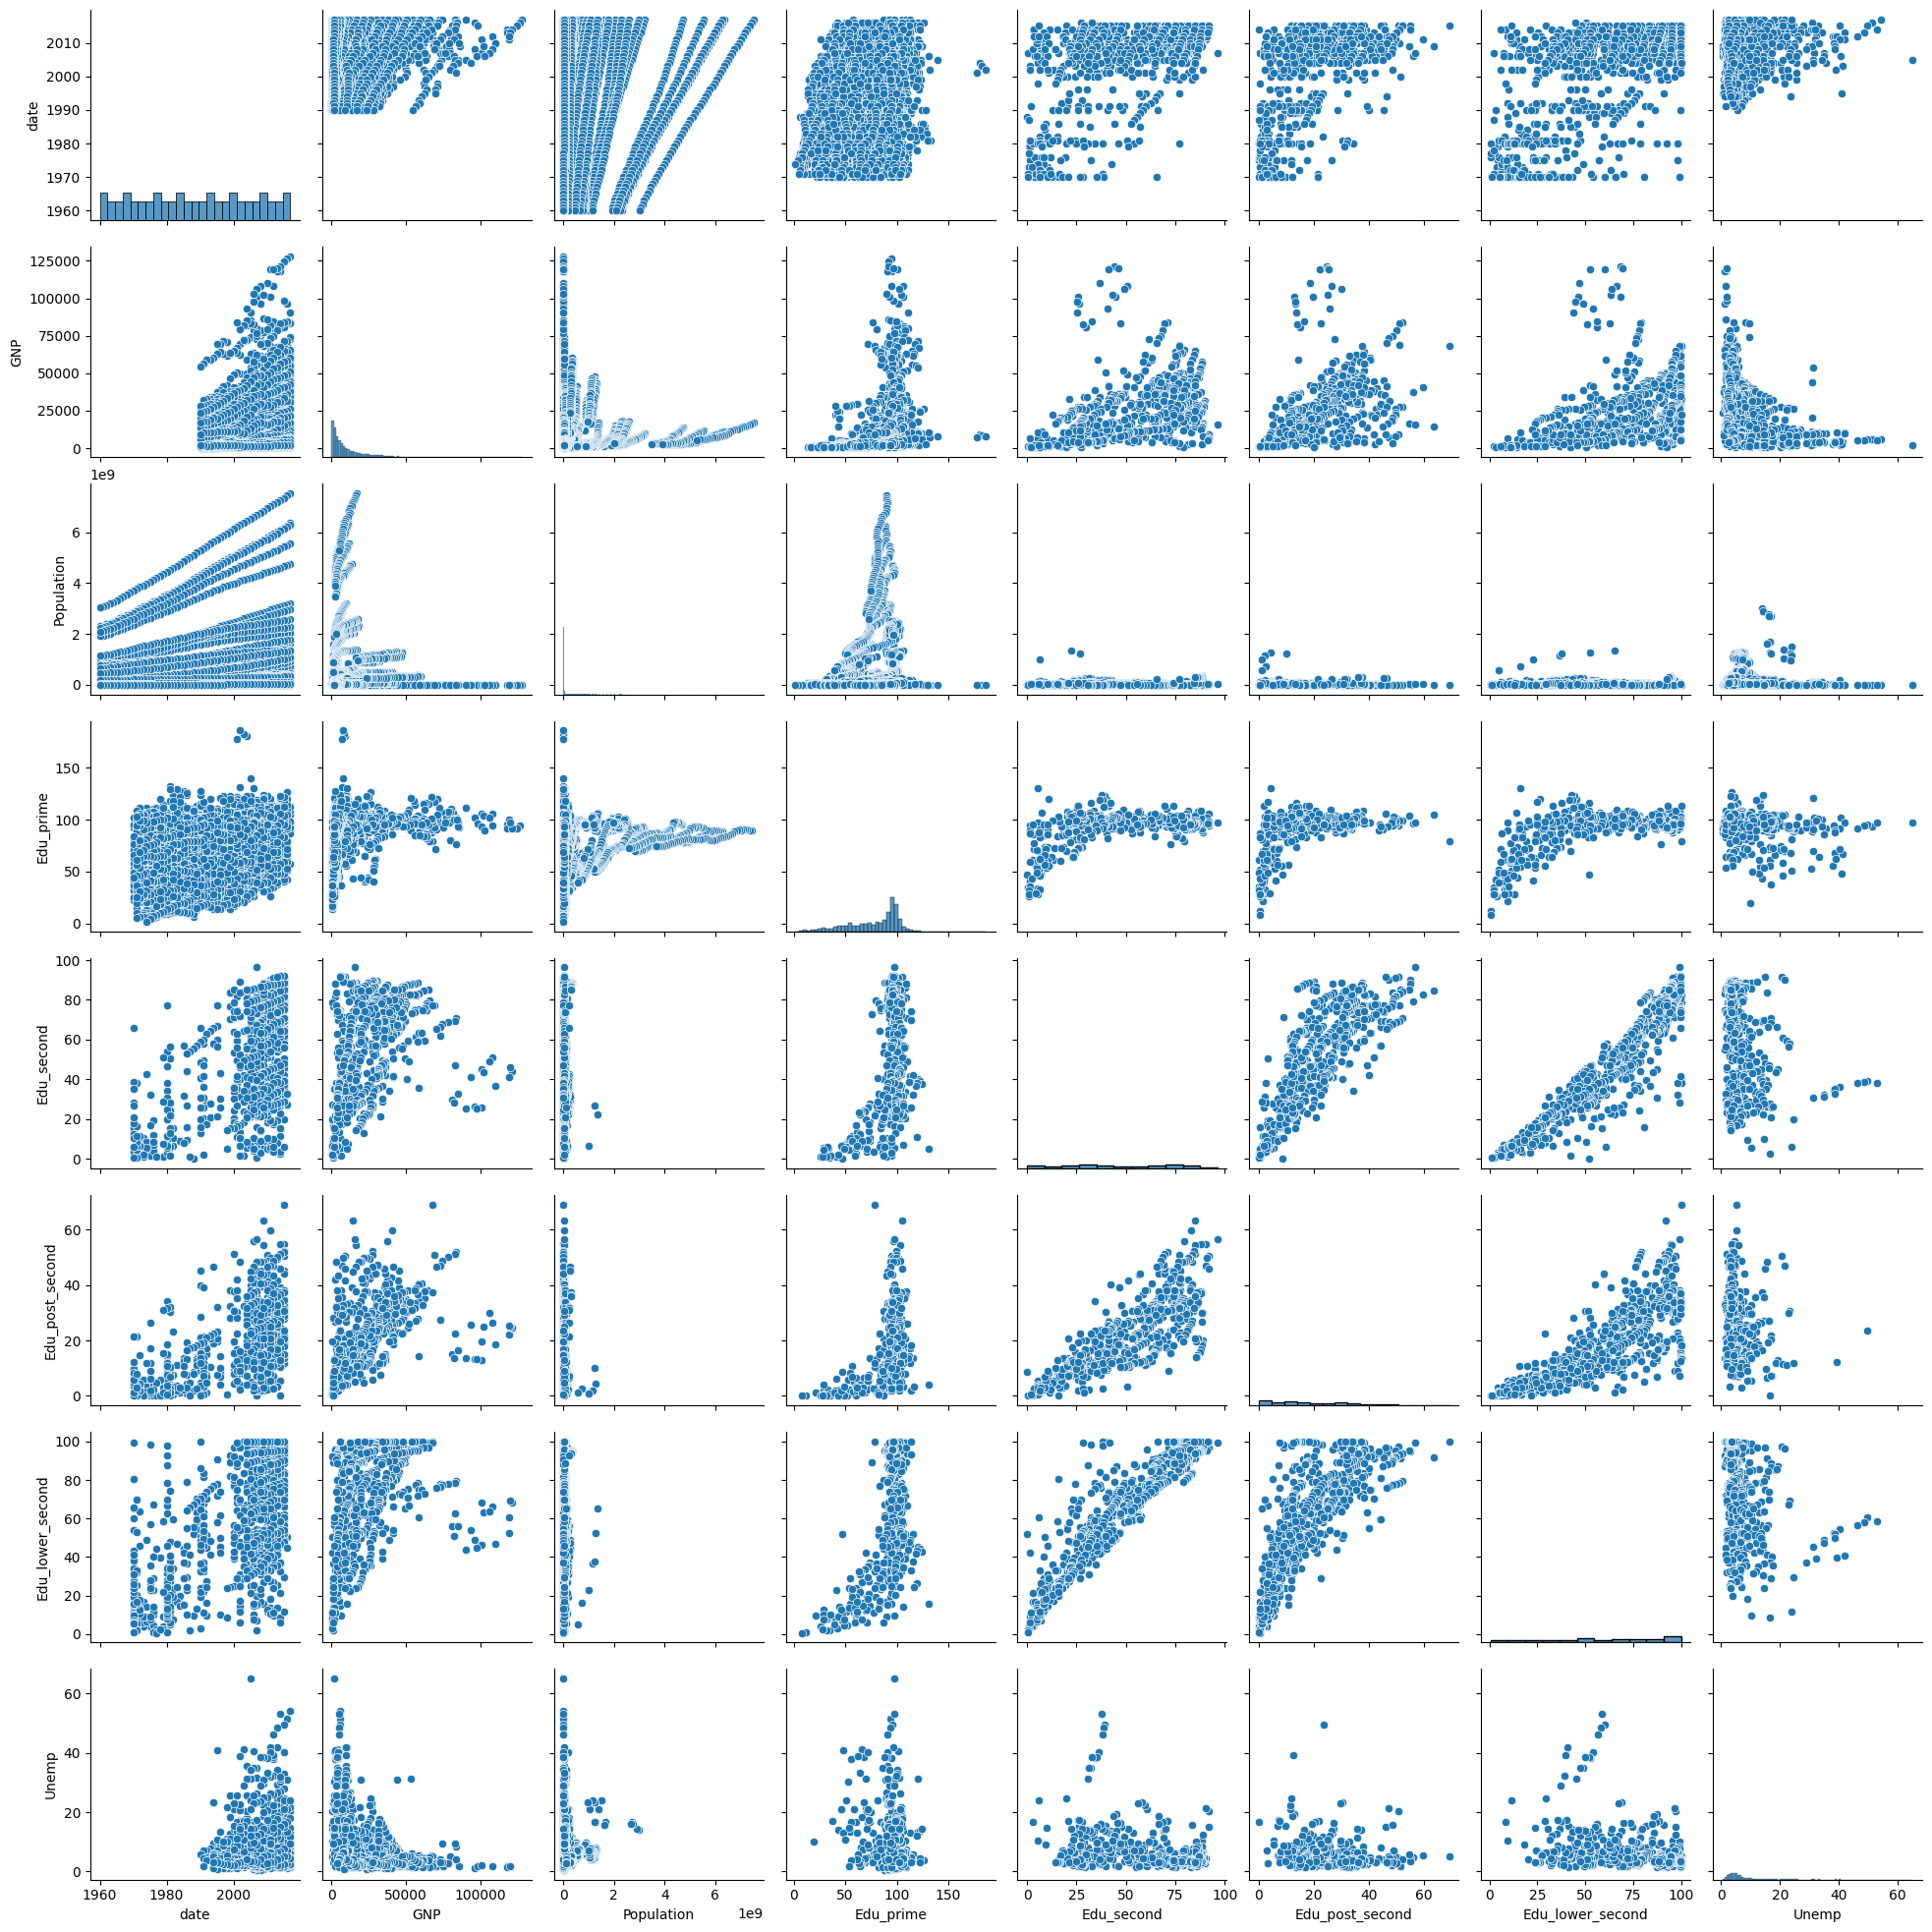

In [26]:
numeric_df = df.select_dtypes(include=['int64','float64'])

sns.pairplot(numeric_df)
plt.show()

Count Plot (Better categorical visualization)

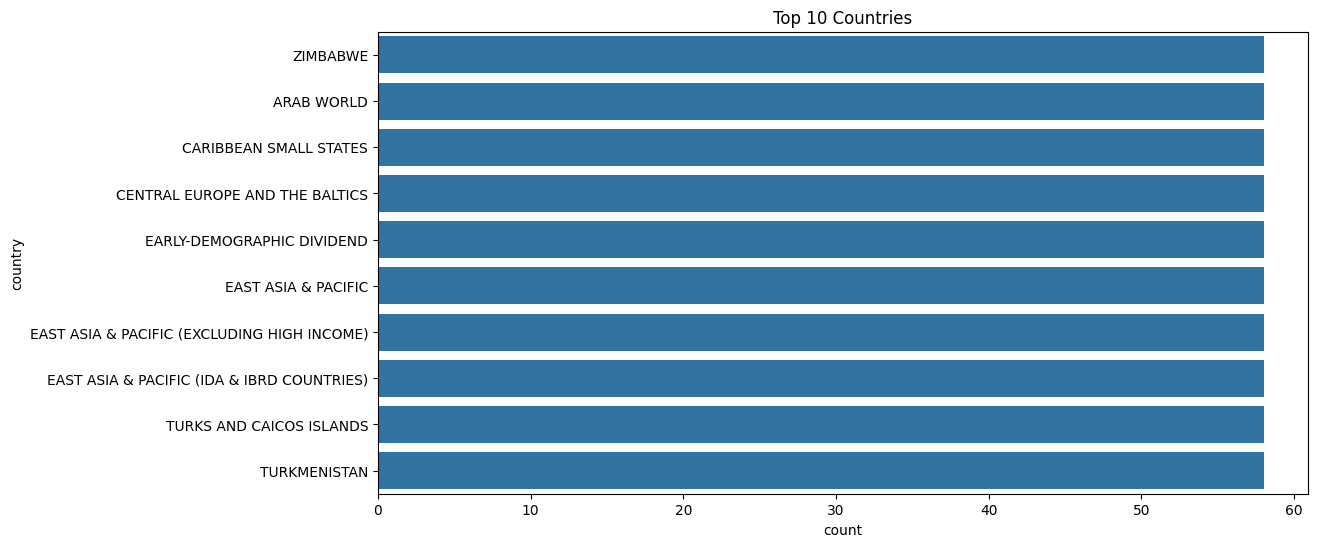

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.countplot(y="country", data=df, order=df["country"].value_counts().index[:10])
plt.title("Top 10 Countries")
plt.show()

KDE Plot (Distribution Curve)

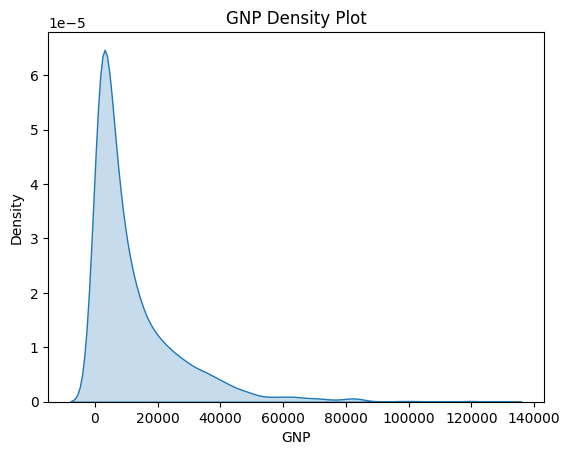

In [32]:
sns.kdeplot(df["GNP"], fill=True)
plt.title("GNP Density Plot")
plt.show()